In [368]:
# import path
import sys
sys.path.append("../src/")
sys.path.append("../")
from segment2d import *
from segment2d.model import *
import numpy as np

from natsort import natsorted
import configparser
from pathlib import Path
import pandas as pd
import os
from omegaconf import OmegaConf
from tqdm import tqdm
from matplotlib import pyplot as plt
# import interact 
from ipywidgets import interact


In [369]:
cfg_train = OmegaConf.load("../config/train_config.yaml")
cfg_data = OmegaConf.load("../config/data_config.yaml")
num_classes_dict = {}
for cmr_type in cfg_data.CMR_MULTI:
    num_classes_dict[cmr_type] = {}
    for cmr_view in cfg_data.CMR_MULTI[cmr_type]:
        num_classes_dict[cmr_type][cmr_view] = cfg_data.CMR_MULTI[cmr_type][cmr_view].num_classes
model = MultiHeadFCDenseNet(in_channels=cfg_train.INPUT_DIM_MODEL, head_classes=num_classes_dict[cmr_type])

In [11]:
# PROJECT_ROOT = src_dir.parent
# config_dir = PROJECT_ROOT / "config"
# saved_model_dir = PROJECT_ROOT / "saved_models"
cfg_train = OmegaConf.load("../config/train_config.yaml")
cfg_data = OmegaConf.load("../config/data_config.yaml")
num_classes_dict = {}
for cmr_type in cfg_data.CMR_MULTI:
    num_classes_dict[cmr_type] = {}
    for cmr_view in cfg_data.CMR_MULTI[cmr_type]:
        num_classes_dict[cmr_type][cmr_view] = cfg_data.CMR_MULTI[cmr_type][cmr_view].num_classes
print(num_classes_dict)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("../output", exist_ok=True)
save_dir = "../output/"
input_dir = "../input/"
for i, cmr_type_path in enumerate(glob.glob(os.path.join(input_dir, "*/*VAL")), start=1):
    cmr_type = os.path.basename(cmr_type_path)
    task_dir = f"task{i}_{cmr_type.lower().split('_')[0]}"
    os.makedirs(os.path.join(save_dir, task_dir), exist_ok=True)
    for cmr_view_path in glob.glob(os.path.join(cmr_type_path, "*")):
        print(f"Processing {cmr_type} - {cmr_view_path}...")
        cmr_view = os.path.basename(cmr_view_path).split("_")[0]
        os.makedirs(os.path.join(save_dir, task_dir, cmr_view), exist_ok=True)
        list_patient = glob.glob(os.path.join(cmr_view_path, "image/*"))
        model = MultiHeadFCDenseNet(in_channels=cfg_train.INPUT_DIM_MODEL, head_classes=num_classes_dict[cmr_type])
        model = torch.compile(model)
        for image_path in tqdm(list_patient):
            patient_name = os.path.basename(image_path)
            # data = preprocess_data_nii(image_path)
            # num_class = num_classes_dict[cmr_type][cmr_view]
            # prob = np.zeros((data["image"].shape[0], num_class, data["image"].shape[2], data["image"].shape[3]))
            # for fold in range(1, 6):
            #     if fold != 1:
            #         continue
            #     checkpoint = torch.load(saved_model_dir / f"CINE_fold1/dice_0.8712.ckpt", map_location=device)
            #     state_dict = {k.replace("model.", ""): v for k, v in checkpoint["state_dict"].items()}
            #     model.load_state_dict(state_dict)
            #     model = model.eval()
            #     probability_output = predict_patches(
            #         data["image"], model, view=cmr_view, 
            #         num_classes=num_classes_dict[cmr_type][cmr_view], batch_size=8, device=device)
            #     # probability_output shape (n, num_classes, dim_resize, dim_resize)
            #     prob += probability_output
            # # calculate the argmax of the average probability
            # seg = np.argmax(prob, axis=1).transpose(1, 2, 0)  # shape (dim_resize, dim_resize, n)
            # seg = remove_small_elements(seg, min_size_remove=200)
            # invert_seg = restore_mask(seg, data["restore_info"])
            # save_patient_path = os.path.join(save_dir, task_dir, cmr_view, patient_name)
            # save_nii(save_patient_path, invert_seg, data["affine"], data["header"])


# print(list_patient)

{'CINE_MULTI': {'SAX': 4, '2CH': 3, '4CH': 6}, 'LGE_MULTI': {'SAX': 5, '2CH': 4, '4CH': 5, 'RAS': 2}}


In [365]:
mask_path = "/home/nhattm/CMR-MULTI/output/task2_lge/SAX/LGE_SAX_007.nii.gz"
pred = nib.load(mask_path).get_fdata().astype(np.uint8)
header = nib.load(mask_path).header
print(calculate_label3_mass(pred, header))

39.75073666841017


In [366]:
processed_mass = postprocess_scar_between_lv_myo_3d(
    pred,
    min_ratio=0.03,
    max_ratio=0.4,
    min_scar_voxels=50,
    min_component_voxels=2,
    myo_dilation_iter=4,
    lv_dilation_iter =4,
    max_reduce_fraction=0.1,
    
)
calculate_label3_mass(processed_mass, header)

np.float64(39.711462828370806)

In [370]:
# load json
import json
gt_mask_path = "/home/nhattm/CMR-MULTI/mass_predictions_gt.json"
mask_path = "/home/nhattm/CMR-MULTI/output/task2_lge/mass_predictions.json"
#load json files
with open(gt_mask_path, 'r') as f:
    gt_data = json.load(f)
with open(mask_path, 'r') as f:
    pred_data = json.load(f)
# calculate peason correlation coefficient
from scipy.stats import pearsonr
gt_masses = []
pred_masses = []
for patient in gt_data:
    gt_masses.append(gt_data[patient])
    pred_masses.append(pred_data[patient])
pearson_corr, _ = pearsonr(gt_masses, pred_masses)
print(f"Pearson correlation coefficient: {pearson_corr:.4f}")

Pearson correlation coefficient: 0.6869


In [145]:
mask = (
    nib.load("/home/nhattm/CMR-MULTI/input/CMR-MULTI/CINE_MULTI/SAX_VAL/anno/CINE_SAX_109.nii.gz")
    .get_fdata()
    .astype(np.uint8)
)

In [147]:
# calculate dice score between pred and mask
def dice_score(pred, mask, class_id=1):
    pred_class = (pred == class_id).astype(np.uint8)
    mask_class = (mask == class_id).astype(np.uint8)
    intersection = np.sum(pred_class * mask_class)
    union = np.sum(pred_class) + np.sum(mask_class)
    if union == 0:
        return 1.0  # Both pred and mask are empty
    return 2.0 * intersection / union
print(f"Dice Score: {dice_score(pred, mask, class_id=1)}")
print(f"Dice Score: {dice_score(pred, mask, class_id=2)}")
print(f"Dice Score: {dice_score(pred, mask, class_id=3)}")



Dice Score: 0.8677243471136961
Dice Score: 0.9128731265327638
Dice Score: 0.9122117175551326


In [4]:
image = nib.load(image_path)
image = image.get_fdata()
mask = nib.load(image_path.replace("image", "anno"))
mask = mask.get_fdata()

(np.float64(-0.5), np.float64(154.5), np.float64(168.5), np.float64(-0.5))

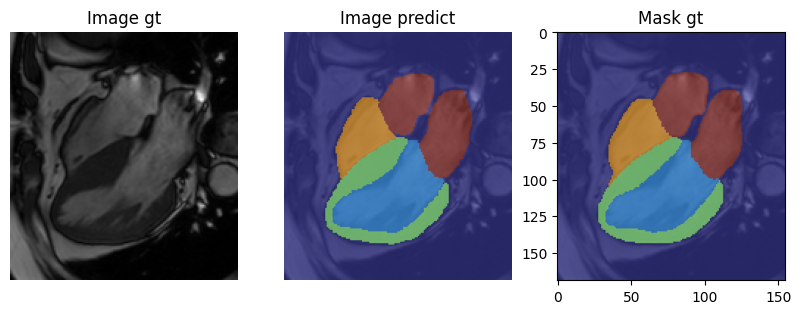

In [7]:
z = 50
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(image[..., z], cmap="gray")
ax[0].set_title("Image gt")
# ax[0].imshow(mask[..., z], cmap="jet", alpha=0.3)
ax[1].imshow(image[..., z], cmap="gray", alpha=0.7)
ax[1].set_title("Image predict")
ax[1].imshow(mask[..., z], cmap="jet", alpha=0.5, vmin=0, vmax=4)

ax[2].imshow(image[..., z], cmap="gray", alpha=0.7)
ax[2].imshow(invert_seg[..., z], cmap="jet", alpha=0.5, vmin=0, vmax=4)
ax[2].set_title("Mask gt")
# off the axis
ax[0].axis('off')
ax[1].axis('off')


In [ ]:
def plot_image_mask_z(image, mask, padded_image, padded_mask, z):
    fig, ax = plt.subplots(1, 3, figsize=(10, 5))
    ax[0].imshow(image[..., z], cmap="gray")
    ax[0].set_title("Image gt")
    # ax[0].imshow(mask[..., z], cmap="jet", alpha=0.3)
    ax[1].imshow(padded_image[..., z], cmap="gray", alpha=0.7)
    ax[1].set_title("Image predict")
    ax[1].imshow(padded_mask[..., z], cmap="jet", alpha=0.5, vmin=0, vmax=4)

    ax[2].imshow(`padded_image`[..., z], cmap="gray", alpha=0.7)
    ax[2].imshow(mask[..., z], cmap="jet", alpha=0.5)
    ax[2].set_title("Mask gt")
    # off the axis
    ax[0].axis('off')
    ax[1].axis('off')


interact(lambda z: plot_image_mask_z(image, mask, image, invert_seg, z), z=(0, image.shape[-1] - 1))